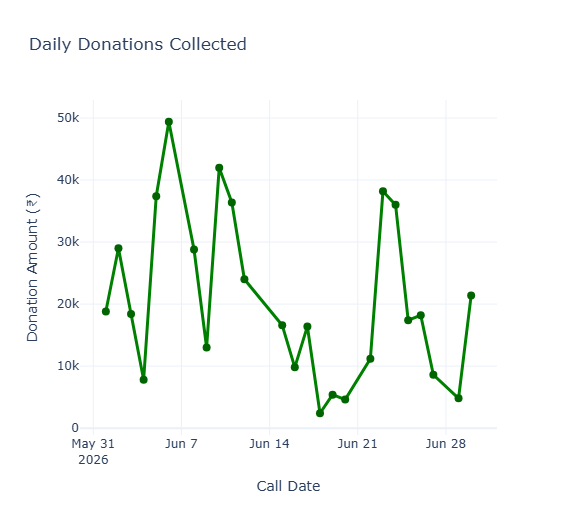

In [ ]:
import pandas as pd
import plotly.express as px

sheet_id = input("Enter Google Sheet ID: ")
sheet_name = input("Enter Sheet Name: ")
gid = input("Enter GID")
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)


df["Call Date"] = pd.to_datetime(df["Call Date"])


df["Donation Amount"] = pd.to_numeric(df["Donation Amount"], errors="coerce")


df = df.dropna(subset=["Donation Amount"])


daily_donations = (
    df.groupby("Call Date")["Donation Amount"]
    .sum()
    .reset_index()
)

fig = px.line(
    daily_donations,
    x="Call Date",
    y="Donation Amount",
    title="Daily Donations Collected",
    markers=True,
    labels={
        "Call Date": "Date",
        "Donation Amount": "Donation Amount (₹)"
    }
)

fig.update_traces(
    line=dict(color="green", width=3),
    marker=dict(size=8, color="darkgreen")
)

fig.update_layout(
    template="plotly_white",
    height=500,
    width=900,
    hovermode="x unified",
    xaxis_title="Call Date",
    yaxis_title="Donation Amount (₹)"
)

fig.show()